# 5 — Model Comparison & Hypothesis Testing

This chapter compares the two modelling approaches from Chapters 3 and 4:

- **Logistic Regression (L1-regularized / LASSO)**: interpretable, coefficient-based
- **Gradient Boosting**: flexible, non-linear, SHAP-based interpretation

Both models were trained on all 12 clinical features (without `source_code`) and are loaded from their saved state — no retraining is performed here.

## Hypothesis

> *Can a classification model based on 5 variables reach a sensitivity (recall) of at least 99% (false-negative rate < 1%) with simultaneous precision of over 80%?*

To test this, we first compare both full models, then train reduced 5-variable versions using only the most influential predictors identified in Chapters 3 and 4.

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
)

FIGURES = "../results/figures"
TABLES  = "../results/tables"
MODELS  = "../results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue  (LogReg)
CLR_RED   = "#CA6B6E"   # muted rose  (GBM)
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "pres_blue", [CLR_GRAY, CLR_BLUE], N=256)
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "pres_red", [CLR_GRAY, CLR_RED], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_BLUE,
    "axes.labelcolor": CLR_BLUE,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_BLUE,
    "xtick.color": CLR_BLUE,
    "ytick.color": CLR_BLUE,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 5.1 — Load Trained Models

Both models were trained on all 12 clinical features (without `source_code`) in Chapters 3 and 4. We load the saved pipelines and recreate the same train/test split to generate predictions.

In [2]:
# Load data and recreate the same split (same RANDOM_STATE ensures identical split)
df = load_processed_data()
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Features: {X.shape[1]}  (no source_code)")
print(f"Columns: {list(X.columns)}")
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Disease prevalence - Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")

Features: 12  (no source_code)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']

Train: 736  |  Test: 184
Disease prevalence - Train: 55.3%  |  Test: 55.4%


In [3]:
# Load saved models from Chapters 3 and 4
pipe_lr = joblib.load(f"{MODELS}/logreg_model.joblib")
pipe_gb = joblib.load(f"{MODELS}/gb_best_model.joblib")

# Predict probabilities on test set
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_prob_gb = pipe_gb.predict_proba(X_test)[:, 1]

print("Models loaded successfully.")
print(f"  LogReg Test ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"  GBM    Test ROC-AUC:  {roc_auc_score(y_test, y_prob_gb):.4f}")

Models loaded successfully.
  LogReg Test ROC-AUC:  0.8895
  GBM    Test ROC-AUC:  0.9093


## 5.2 — ROC Curve Comparison

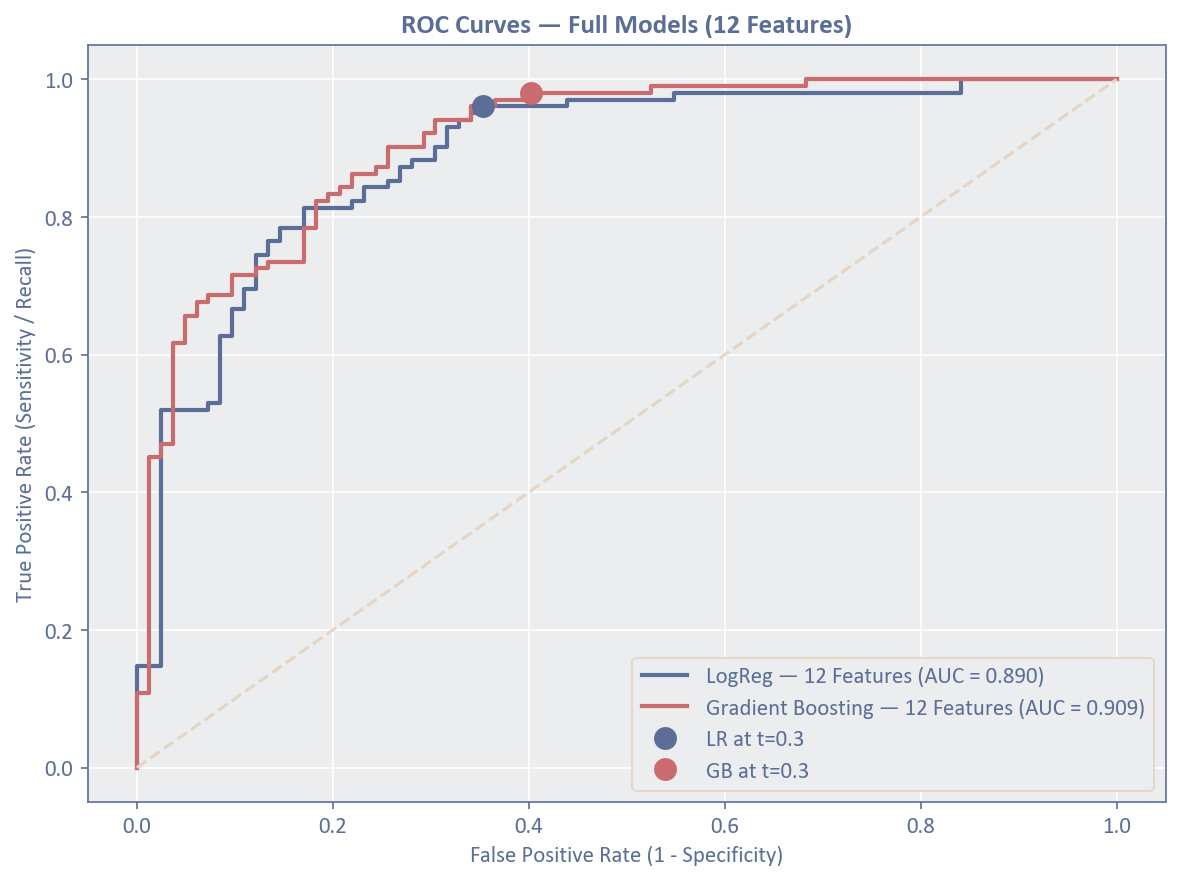

In [4]:
# ROC curves side by side
fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test, y_prob_lr)
fpr_gb, tpr_gb, thresh_gb = roc_curve(y_test, y_prob_gb)
auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, color=CLR_BLUE, lw=2, label=f"LogReg \u2014 12 Features (AUC = {auc_lr:.3f})")
ax.plot(fpr_gb, tpr_gb, color=CLR_RED, lw=2, label=f"Gradient Boosting \u2014 12 Features (AUC = {auc_gb:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark threshold 0.3 on both curves
for fpr_arr, tpr_arr, thresh_arr, color, name in [
    (fpr_lr, tpr_lr, thresh_lr, CLR_BLUE, "LR"),
    (fpr_gb, tpr_gb, thresh_gb, CLR_RED, "GB"),
]:
    idx = np.argmin(np.abs(thresh_arr - 0.3))
    ax.plot(fpr_arr[idx], tpr_arr[idx], "o", color=color, markersize=10,
            label=f"{name} at t=0.3")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curves \u2014 Full Models (12 Features)")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/comparison_roc_curves.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5.3 — Threshold Comparison

Both models use t = 0.3 as the screening threshold. We compare detailed metrics across multiple thresholds.

In [5]:
# Compare both models across thresholds
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]
rows = []

for name, y_prob in [("LogReg (12)", y_prob_lr), ("GBM (12)", y_prob_gb)]:
    for thresh in candidate_thresholds:
        y_pred_t = (y_prob >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred_t)
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            "Model": name,
            "Threshold": thresh,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "Accuracy": accuracy_score(y_test, y_pred_t),
            "Precision": precision_score(y_test, y_pred_t, zero_division=0),
            "Recall": recall_score(y_test, y_pred_t),
            "Specificity": tn / (tn + fp),
            "F1": f1_score(y_test, y_pred_t),
        })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(f"{TABLES}/comparison_threshold_metrics.csv", index=False)

print("Performance comparison \u2014 Full Models (12 Features):\n")
comparison_df.round(4)

Performance comparison — Full Models (12 Features):



,Model,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall,Specificity,F1
0,LogReg (12),0.5,87,21,15,61,0.8043,0.8056,0.8529,0.7439,0.8286
1,LogReg (12),0.4,95,26,7,56,0.8207,0.7851,0.9314,0.6829,0.8520
2,LogReg (12),0.3,98,31,4,51,0.8098,0.7597,0.9608,0.6220,0.8485
3,LogReg (12),0.2,99,39,3,43,0.7717,0.7174,0.9706,0.5244,0.8250
4,GBM (12),0.5,89,20,13,62,0.8207,0.8165,0.8725,0.7561,0.8436
5,GBM (12),0.4,96,25,6,57,0.8315,0.7934,0.9412,0.6951,0.8610
6,GBM (12),0.3,100,34,2,48,0.8043,0.7463,0.9804,0.5854,0.8475
7,GBM (12),0.2,101,43,1,39,0.7609,0.7014,0.9902,0.4756,0.8211


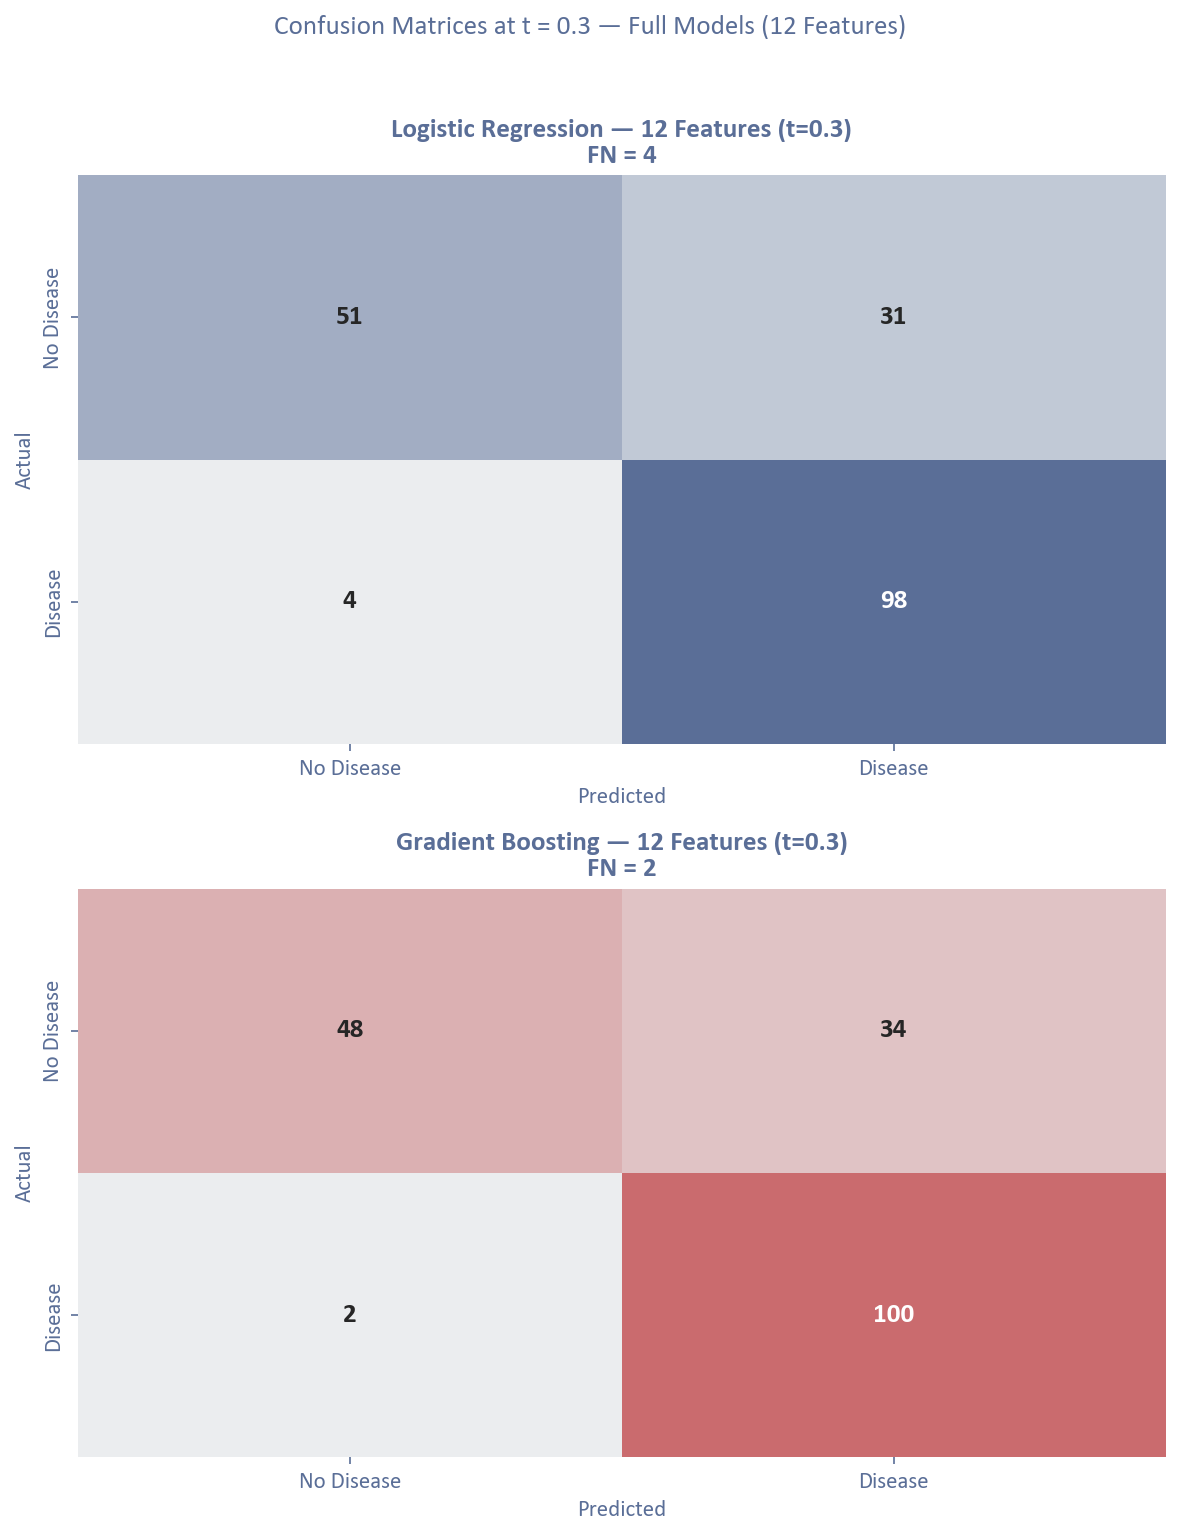

In [6]:
# Confusion matrices at t=0.3 side by side
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
thresh = 0.3

for i, (name, y_prob, cmap) in enumerate([
    ("Logistic Regression \u2014 12 Features", y_prob_lr, CMAP_BLUE),
    ("Gradient Boosting \u2014 12 Features", y_prob_gb, CMAP_RED),
]):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    fn = cm[1, 0]

    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                ax=axes[i], cbar=False,
                annot_kws={"fontsize": 13, "fontweight": "bold"})
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_title(f"{name} (t=0.3)\nFN = {fn}")
    axes[i].grid(False)

fig.suptitle("Confusion Matrices at t = 0.3 \u2014 Full Models (12 Features)", fontsize=13, y=1.02)
fig.savefig(f"{FIGURES}/comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5.4 — Feature Importance Comparison

We compare which features each model considers most important. For logistic regression: aggregated absolute coefficients. For gradient boosting: built-in feature importances (mean decrease in impurity).

Agreement between both models on the top features increases confidence that these carry genuine predictive signal.

In [7]:
# Extract feature importances from both models

_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

def aggregate_importance(feature_names, importances):
    """Aggregate one-hot encoded features back to original variable names."""
    original = {}
    for name, imp in zip(feature_names, importances):
        orig = name
        for mc in _MULTICLASS_ORIGINALS:
            if name.startswith(mc + "_"):
                orig = mc
                break
        original[orig] = original.get(orig, 0) + abs(imp)
    result = pd.DataFrame(list(original.items()), columns=["feature", "importance"])
    result = result.sort_values("importance", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    return result

# Get transformed feature names (clean)
preprocessor_lr = pipe_lr.named_steps["preprocessor"]
feat_names = [f.split("__")[-1] for f in preprocessor_lr.get_feature_names_out()]

# LogReg: absolute coefficients
lr_coefs = pipe_lr.named_steps["classifier"].coef_[0]
imp_lr = aggregate_importance(feat_names, lr_coefs)
imp_lr.columns = ["feature", "lr_importance", "lr_rank"]

# GBM: built-in feature importance
preprocessor_gb = pipe_gb.named_steps["preprocessor"]
feat_names_gb = [f.split("__")[-1] for f in preprocessor_gb.get_feature_names_out()]
gb_imp = pipe_gb.named_steps["classifier"].feature_importances_
imp_gb = aggregate_importance(feat_names_gb, gb_imp)
imp_gb.columns = ["feature", "gb_importance", "gb_rank"]

# Merge
rank_comparison = imp_lr.merge(imp_gb, on="feature", how="outer")
rank_comparison = rank_comparison.sort_values("lr_rank").reset_index(drop=True)
rank_comparison.to_csv(f"{TABLES}/comparison_feature_ranking.csv", index=False)

print("Feature ranking comparison (without source_code):\n")
rank_comparison

Feature ranking comparison (without source_code):



,feature,lr_importance,lr_rank,gb_importance,gb_rank
0,cp,2.446818,1,0.426989,1
1,thal,1.481969,2,0.046715,7
2,sex,1.303963,3,0.089151,5
3,exang,0.770049,4,0.103186,2
4,restecg,0.524919,5,0.003080,12
5,oldpeak,0.476962,6,0.091271,3
6,thalach,0.395584,7,0.090238,4
7,age,0.292989,8,0.083492,6
8,slope,0.239118,9,0.003206,11
9,chol,0.214378,10,0.046247,8


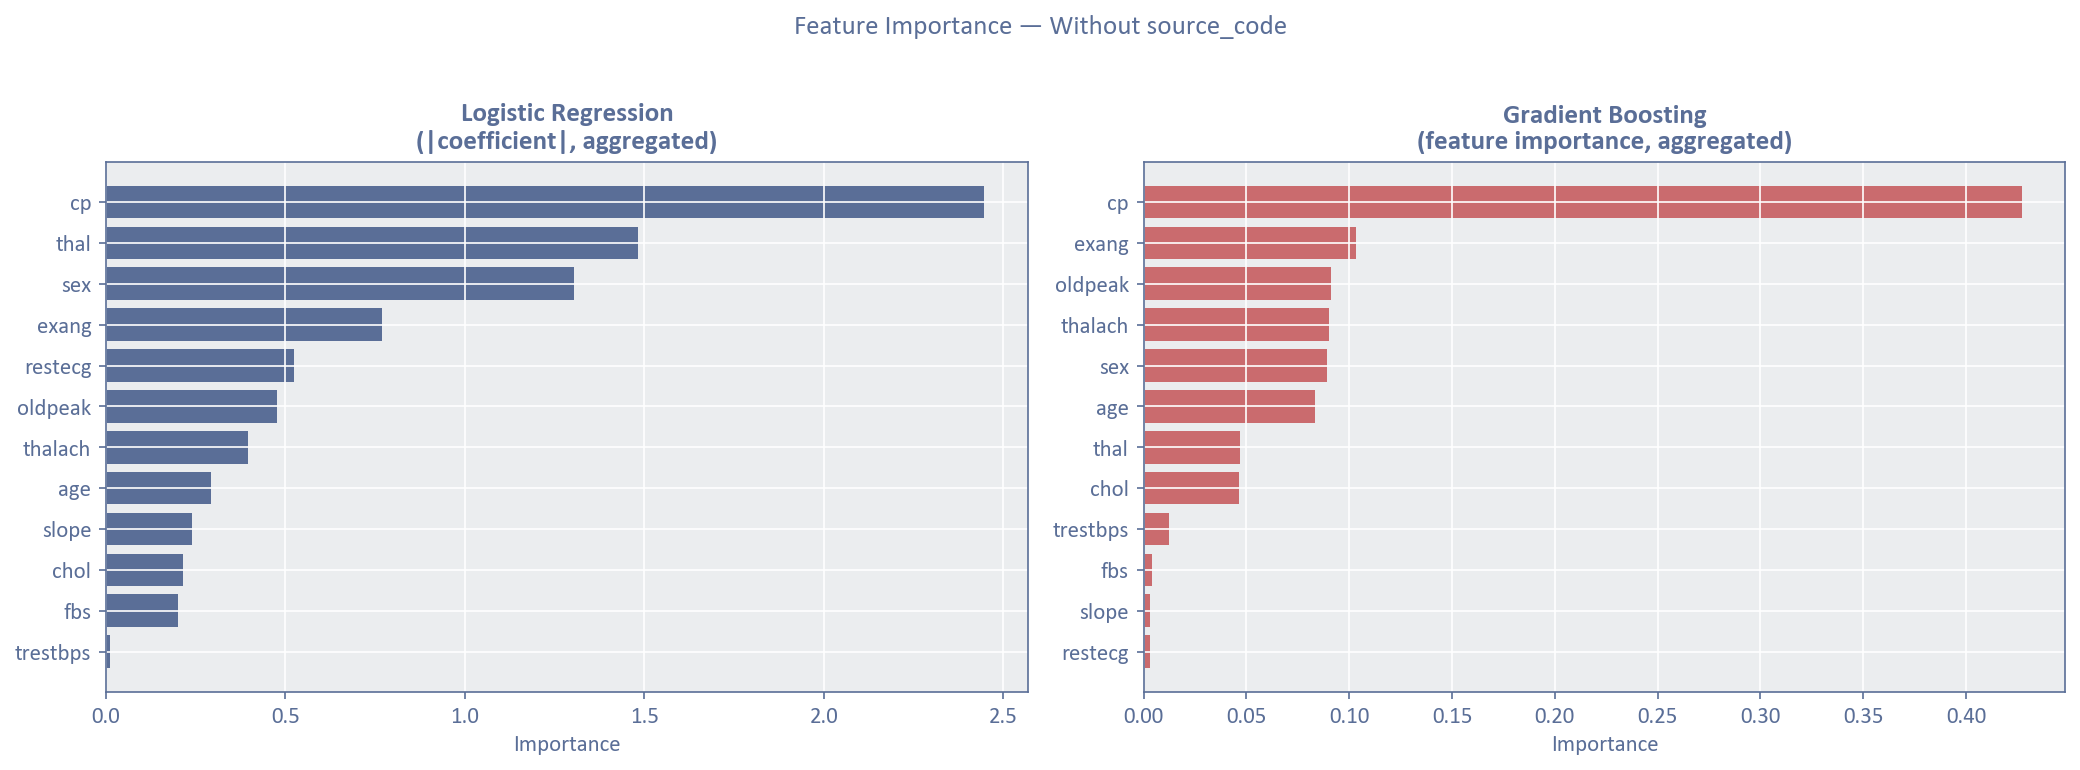

In [8]:
# Visual comparison of feature rankings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LogReg
lr_sorted = rank_comparison.sort_values("lr_importance", ascending=True)
axes[0].barh(lr_sorted["feature"], lr_sorted["lr_importance"], color=CLR_BLUE)
axes[0].set_title("Logistic Regression\n(|coefficient|, aggregated)")
axes[0].set_xlabel("Importance")

# GBM
gb_sorted = rank_comparison.sort_values("gb_importance", ascending=True)
axes[1].barh(gb_sorted["feature"], gb_sorted["gb_importance"], color=CLR_RED)
axes[1].set_title("Gradient Boosting\n(feature importance, aggregated)")
axes[1].set_xlabel("Importance")

fig.suptitle("Feature Importance \u2014 Without source_code", fontsize=13, y=1.02)
fig.savefig(f"{FIGURES}/comparison_feature_importance.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5.5 — Top 5 Variables & Why the Models Disagree

Both models rank **cp** (chest pain type) as the single most important predictor. Beyond that, they diverge:

| Rank | Logistic Regression | Gradient Boosting |
|------|---------------------|-------------------|
| 1 | cp | cp |
| 2 | thal | exang |
| 3 | sex | oldpeak |
| 4 | exang | thalach |
| 5 | restecg | sex |

**Why the difference?** Logistic regression measures each feature's *linear* contribution to the log-odds. It can capture strong categorical separations (e.g. `thal = reversible defect` vs. `thal = normal`) efficiently through one-hot encoding. Gradient boosting, by contrast, builds decision trees that split on continuous thresholds — it naturally favours continuous variables (`oldpeak`, `thalach`) where it can find optimal cut points. Additionally, gradient boosting captures non-linear interactions between variables, so a feature that is individually weak (like `thalach`) may still rank high because it interacts with other splits in the tree ensemble.

**Cross-model validation:** Despite different ranking methods, both models agree that **cp**, **sex**, and **exang** are among the top 5 predictors. This convergence from two fundamentally different algorithms strengthens confidence in these variables as genuinely informative clinical features.

For the reduced screening model, we use **logistic regression's top 5** because: (a) logistic regression is the interpretable model intended for clinical use, and (b) L1 regularization provides a principled, embedded feature selection mechanism. The variables are: **cp, thal, sex, exang, restecg**.

In [9]:
# Show top 5 from each model
print("TOP 5 — LOGISTIC REGRESSION (|coefficient|, aggregated)")
print("=" * 55)
for _, row in imp_lr.head(5).iterrows():
    print(f"  {int(row['lr_rank'])}. {row['feature']:15s}  ({row['lr_importance']:.4f})")

print(f"\nTOP 5 — GRADIENT BOOSTING (feature importance, aggregated)")
print("=" * 55)
for _, row in imp_gb.head(5).iterrows():
    print(f"  {int(row['gb_rank'])}. {row['feature']:15s}  ({row['gb_importance']:.4f})")

print("\n--> For the 5-variable hypothesis test we use the")
print("    logistic regression top 5: cp, thal, sex, exang, restecg")

TOP 5 — LOGISTIC REGRESSION (|coefficient|, aggregated)
  1. cp               (2.4468)
  2. thal             (1.4820)
  3. sex              (1.3040)
  4. exang            (0.7700)
  5. restecg          (0.5249)

TOP 5 — GRADIENT BOOSTING (feature importance, aggregated)
  1. cp               (0.4270)
  2. exang            (0.1032)
  3. oldpeak          (0.0913)
  4. thalach          (0.0902)
  5. sex              (0.0892)

--> For the 5-variable hypothesis test we use the
    logistic regression top 5: cp, thal, sex, exang, restecg


## 5.6 — Summary Table (Full Models, 12 Features)

In [10]:
# Final summary table — full models (12 features)
auc_lr_test = roc_auc_score(y_test, y_prob_lr)
auc_gb_test = roc_auc_score(y_test, y_prob_gb)

def metrics_at_threshold(y_true, y_prob, t):
    y_pred = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Sensitivity": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "FN": fn,
        "FP": fp,
        "F1": f1_score(y_true, y_pred),
    }

m_lr = metrics_at_threshold(y_test, y_prob_lr, 0.3)
m_gb = metrics_at_threshold(y_test, y_prob_gb, 0.3)

summary = pd.DataFrame({
    "Metric": [
        "Test ROC-AUC",
        "Sensitivity (t=0.3)", "Precision (t=0.3)", "Accuracy (t=0.3)",
        "Specificity (t=0.3)",
        "False Negatives (t=0.3)", "False Positives (t=0.3)",
        "F1 (t=0.3)",
        "Interpretable?", "Recommended?"
    ],
    "LogReg (12 Features)": [
        f"{auc_lr_test:.4f}",
        f"{m_lr['Sensitivity']:.4f}", f"{m_lr['Precision']:.4f}", f"{m_lr['Accuracy']:.4f}",
        f"{m_lr['Specificity']:.4f}",
        m_lr["FN"], m_lr["FP"],
        f"{m_lr['F1']:.4f}",
        "Yes", "Yes"
    ],
    "GBM (12 Features)": [
        f"{auc_gb_test:.4f}",
        f"{m_gb['Sensitivity']:.4f}", f"{m_gb['Precision']:.4f}", f"{m_gb['Accuracy']:.4f}",
        f"{m_gb['Specificity']:.4f}",
        m_gb["FN"], m_gb["FP"],
        f"{m_gb['F1']:.4f}",
        "No (black box)", "No"
    ],
})

summary.to_csv(f"{TABLES}/comparison_summary.csv", index=False)
print("Full Model Comparison (12 clinical features):\n")
summary

Full Model Comparison (12 clinical features):



,Metric,LogReg (12 Features),GBM (12 Features)
0,Test ROC-AUC,0.8895,0.9093
1,Sensitivity (t=0.3),0.9608,0.9804
2,Precision (t=0.3),0.7597,0.7463
3,Accuracy (t=0.3),0.8098,0.8043
4,Specificity (t=0.3),0.6220,0.5854
5,False Negatives (t=0.3),4,2
6,False Positives (t=0.3),31,34
7,F1 (t=0.3),0.8485,0.8475
8,Interpretable?,Yes,No (black box)
9,Recommended?,Yes,No


## 5.7 — Hypothesis Test: 5-Variable Logistic Regression

> **Hypothesis:** *Can a classification model based on 5 variables reach sensitivity >= 99% (FNR < 1%) with simultaneous precision > 80%?*

### Feature Selection Method

The 5 variables were selected using **L1 (LASSO) regularization** from the logistic regression trained in Chapter 3. L1 penalises the sum of absolute coefficients during training, shrinking weak predictors towards zero. The features with the largest surviving absolute coefficients are the most influential. By aggregating coefficients of one-hot encoded categories back to their original variable names, we obtain a principled importance ranking.

This is **embedded feature selection** — the regularization itself identifies the important features as part of training. It differs from wrapper methods like Recursive Feature Elimination (RFE), which iteratively remove features and retrain the model (discussed in the outlook, Section 5.10).

| Variable | Type | Meaning |
|----------|------|---------|
| **cp** | categorical (4 levels) | chest pain type (1=typical, 2=atypical, 3=non-anginal, 4=asymptomatic) |
| **thal** | categorical (3 levels) | thallium stress test result (3=normal, 6=fixed defect, 7=reversible defect) |
| **sex** | binary | 0=female, 1=male |
| **exang** | binary | exercise-induced angina (0=no, 1=yes) |
| **restecg** | binary/categorical | resting ECG (0=normal, 1=ST-T abnormality, 2=LV hypertrophy) |

The multi-class variables are one-hot encoded (with `drop_first=True`), expanding the 5 clinical variables into 9 model inputs. Since all variables are binary or categorical, no standardisation is required.

In [11]:
# Prepare 5-variable dataset using LogReg top 5
FIVE_VARS = ["cp", "thal", "sex", "exang", "restecg"]
X_5_raw = df[FIVE_VARS].copy()
y_5 = df["num"]

# One-hot encode multi-class variables, keep binary as-is
X_5 = pd.get_dummies(X_5_raw, columns=["cp", "thal", "restecg"], drop_first=True, dtype=int)

print(f"5 clinical variables \u2192 {X_5.shape[1]} model inputs after encoding:")
print(f"  {list(X_5.columns)}")

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_5, y_5, test_size=0.2, stratify=y_5, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic regression on 5 variables (no standardisation needed — all binary/categorical)
lr_5 = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
)
lr_5.fit(X_train_5, y_train_5)
cv_lr_5 = cross_val_score(lr_5, X_train_5, y_train_5, cv=cv, scoring="roc_auc")
y_prob_5 = lr_5.predict_proba(X_test_5)[:, 1]
auc_5 = roc_auc_score(y_test_5, y_prob_5)

print(f"\n{'='*55}")
print(f"5-Variable Logistic Regression (5 Features)")
print(f"{'='*55}")
print(f"  CV ROC-AUC:   {cv_lr_5.mean():.4f} +/- {cv_lr_5.std():.4f}")
print(f"  Per fold:     {np.round(cv_lr_5, 4)}")
print(f"  Test ROC-AUC: {auc_5:.4f}")

5 clinical variables → 9 model inputs after encoding:
  ['sex', 'exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'thal_6.0', 'thal_7.0', 'restecg_1.0', 'restecg_2.0']

5-Variable Logistic Regression (5 Features)
  CV ROC-AUC:   0.8556 +/- 0.0172
  Per fold:     [0.8391 0.8329 0.8766 0.8583 0.8711]
  Test ROC-AUC: 0.8625


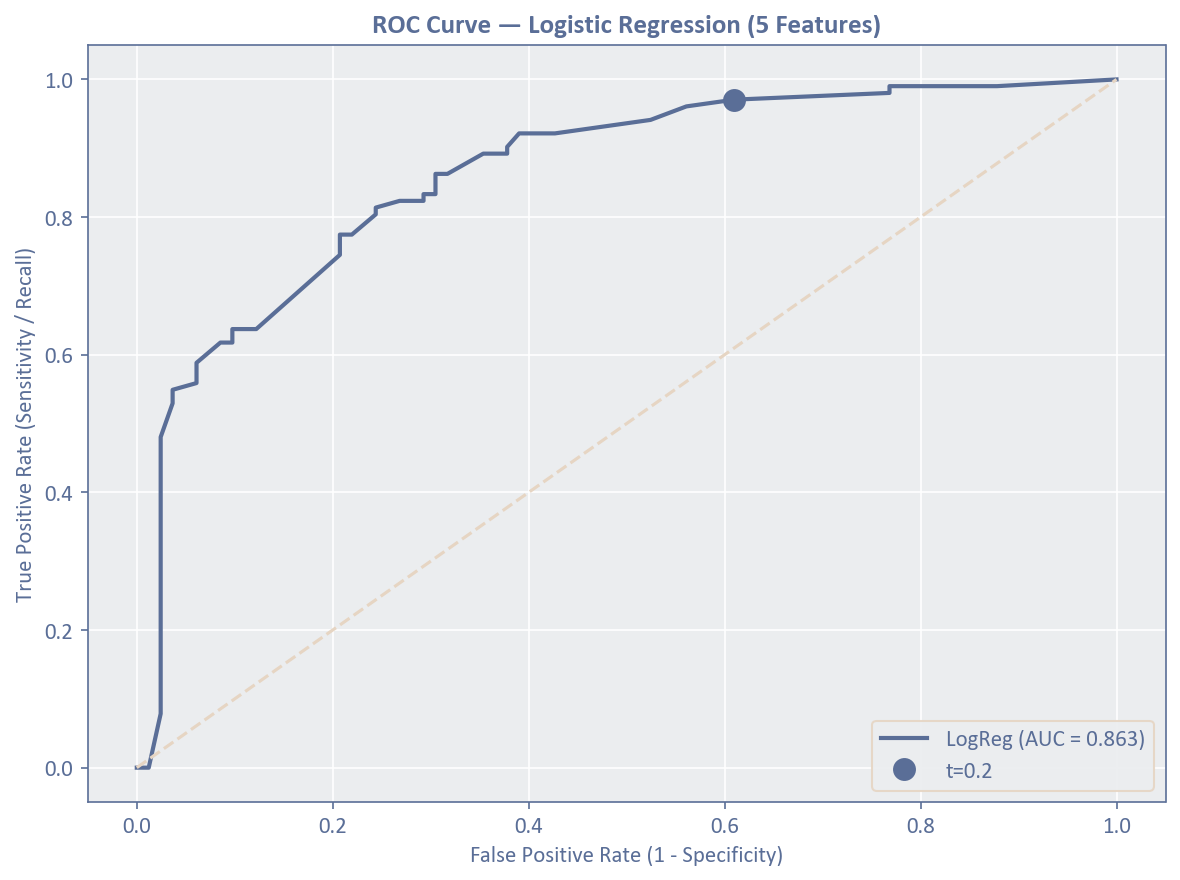

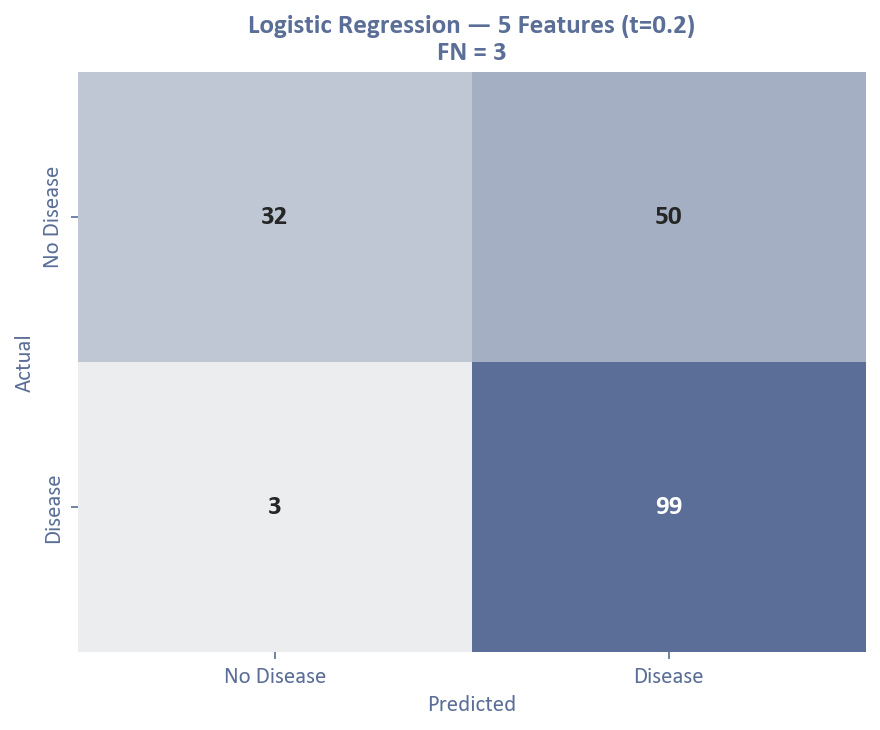

In [12]:
# --- ROC Curve: 5-Variable Logistic Regression ---
fpr_5, tpr_5, thresh_5 = roc_curve(y_test_5, y_prob_5)
auc_5_val = auc(fpr_5, tpr_5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_5, tpr_5, color=CLR_BLUE, lw=2, label=f"LogReg (AUC = {auc_5_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark t=0.2
idx = np.argmin(np.abs(thresh_5 - 0.2))
ax.plot(fpr_5[idx], tpr_5[idx], "o", color=CLR_BLUE, markersize=10, label=f"t=0.2")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve \u2014 Logistic Regression (5 Features)")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/logreg_5var_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- Confusion Matrix: 5-Variable at t=0.2 ---
y_pred_5_t02 = (y_prob_5 >= 0.2).astype(int)
cm_5 = confusion_matrix(y_test_5, y_pred_5_t02)
fn_5 = cm_5[1, 0]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_5, annot=True, fmt="d", cmap=CMAP_BLUE,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"],
            ax=ax, cbar=False,
            annot_kws={"fontsize": 13, "fontweight": "bold"})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Logistic Regression \u2014 5 Features (t=0.2)\nFN = {fn_5}")
ax.grid(False)
fig.savefig(f"{FIGURES}/logreg_5var_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

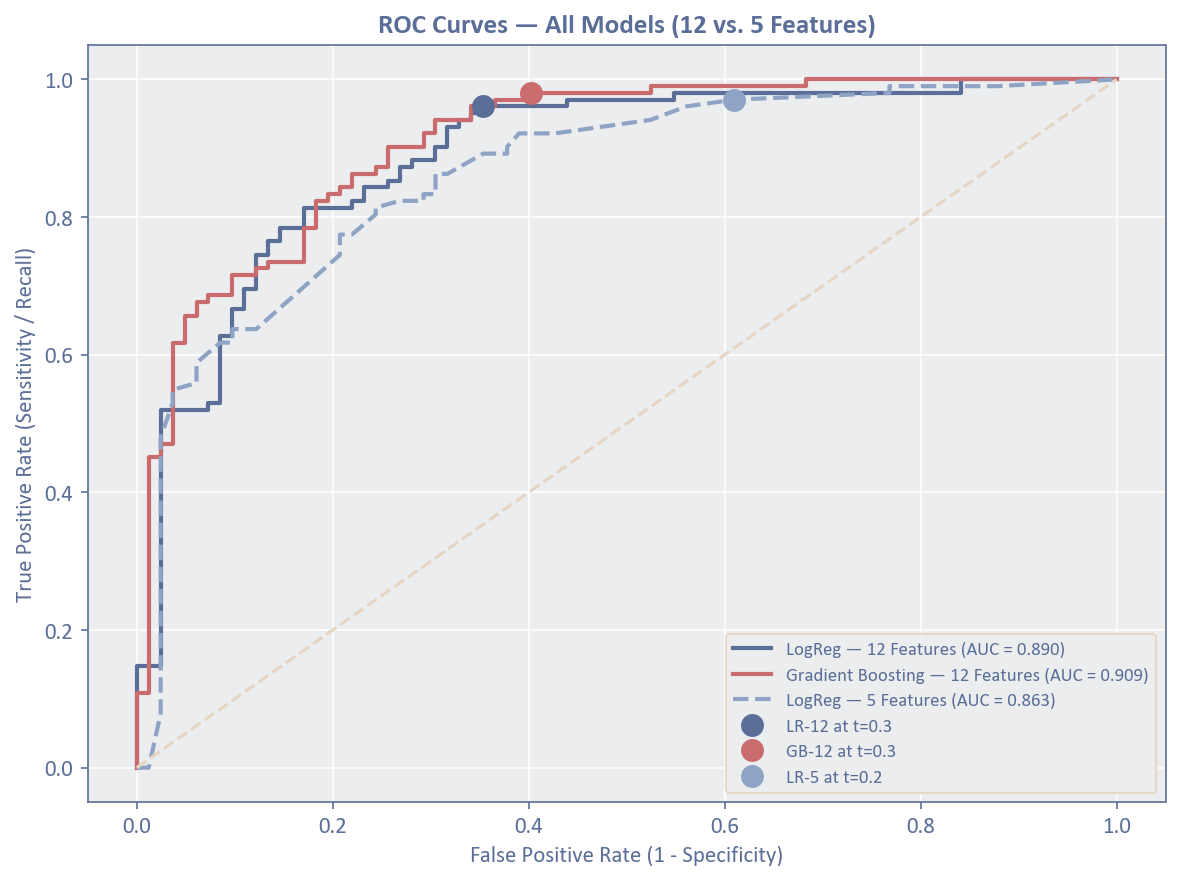

In [13]:
# --- Combined ROC Comparison: All 3 Models ---
CLR_BLUE_LIGHT = "#8FA3C4"  # lighter blue for 5-var model

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_lr, tpr_lr, color=CLR_BLUE, lw=2,
        label=f"LogReg \u2014 12 Features (AUC = {auc_lr:.3f})")
ax.plot(fpr_gb, tpr_gb, color=CLR_RED, lw=2,
        label=f"Gradient Boosting \u2014 12 Features (AUC = {auc_gb:.3f})")
ax.plot(fpr_5, tpr_5, color=CLR_BLUE_LIGHT, lw=2, ls="--",
        label=f"LogReg \u2014 5 Features (AUC = {auc_5_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark operating thresholds on all curves (t=0.3 for 12-feat, t=0.2 for 5-feat)
for fpr_arr, tpr_arr, thresh_arr, color, name, t in [
    (fpr_lr, tpr_lr, thresh_lr, CLR_BLUE, "LR-12", 0.3),
    (fpr_gb, tpr_gb, thresh_gb, CLR_RED, "GB-12", 0.3),
    (fpr_5,  tpr_5,  thresh_5,  CLR_BLUE_LIGHT, "LR-5", 0.2),
]:
    idx = np.argmin(np.abs(thresh_arr - t))
    ax.plot(fpr_arr[idx], tpr_arr[idx], "o", color=color, markersize=10,
            label=f"{name} at t={t}")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curves \u2014 All Models (12 vs. 5 Features)")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(f"{FIGURES}/comparison_roc_all_models.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [14]:
# === THE SCREENING FORMULA ===
b = lr_5.coef_[0]
b0 = lr_5.intercept_[0]

print("SCREENING FORMULA (5-Variable Logistic Regression)")
print("=" * 55)
print(f"\n  z = {b0:+.4f}  (intercept)")
for name, coef in zip(X_5.columns, b):
    print(f"      {coef:+.4f} * {name}")
print(f"\n  score = 1 / (1 + exp(-z))")
print(f"\n  If score > 0.2  -->  REFER to cardiologist")

# === HYPOTHESIS EVALUATION ===
print(f"\n\n{'='*55}")
print("HYPOTHESIS EVALUATION")
print(f"{'='*55}")
print(f"Target: sensitivity >= 99% AND precision > 80%\n")

candidate_thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
rows_hypo = []

for thresh in candidate_thresholds:
    y_pred_t = (y_prob_5 >= thresh).astype(int)
    cm = confusion_matrix(y_test_5, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    sens = recall_score(y_test_5, y_pred_t)
    prec = precision_score(y_test_5, y_pred_t, zero_division=0)
    rows_hypo.append({
        "Threshold": thresh,
        "Sensitivity": sens, "Precision": prec,
        "Accuracy": accuracy_score(y_test_5, y_pred_t),
        "FN": fn, "FP": fp,
        "Sens >= 99%": "YES" if sens >= 0.99 else "no",
        "Prec > 80%": "YES" if prec > 0.80 else "no",
        "Hypothesis met": "YES" if (sens >= 0.99 and prec > 0.80) else "no",
    })

hypo_df = pd.DataFrame(rows_hypo)
hypo_df.to_csv(f"{TABLES}/hypothesis_5var_results.csv", index=False)
hypo_df.round(4)

SCREENING FORMULA (5-Variable Logistic Regression)

  z = -1.5785  (intercept)
      +1.2858 * sex
      +1.2801 * exang
      -1.6055 * cp_2.0
      -0.5261 * cp_3.0
      +0.8323 * cp_4.0
      +0.5555 * thal_6.0
      +1.1318 * thal_7.0
      +0.5964 * restecg_1.0
      -0.0404 * restecg_2.0

  score = 1 / (1 + exp(-z))

  If score > 0.2  -->  REFER to cardiologist


HYPOTHESIS EVALUATION
Target: sensitivity >= 99% AND precision > 80%



,Threshold,Sensitivity,Precision,Accuracy,FN,FP,Sens >= 99%,Prec > 80%,Hypothesis met
0,0.5,0.8333,0.7798,0.7772,17,24,no,no,no
1,0.4,0.8922,0.7521,0.7772,11,30,no,no,no
2,0.3,0.9412,0.6906,0.7337,6,43,no,no,no
3,0.2,0.9706,0.6644,0.7120,3,50,no,no,no
4,0.1,0.9902,0.5872,0.6087,1,71,YES,no,no


In [15]:
# === EXAMPLE PATIENTS ===
print("EXAMPLE RISK SCORES")
print("=" * 55)
print(f"Variables: sex, exang, cp (1-4), thal (3/6/7), restecg (0/1/2)")
print(f"Threshold: score > 0.2 -> REFER\n")

def compute_score(sex, exang, cp, thal, restecg):
    """Compute risk score from 5 raw clinical values."""
    # One-hot encode (same as drop_first=True encoding)
    row = {
        "sex": sex, "exang": exang,
        "cp_2.0": int(cp == 2), "cp_3.0": int(cp == 3), "cp_4.0": int(cp == 4),
        "thal_6.0": int(thal == 6), "thal_7.0": int(thal == 7),
        "restecg_1.0": int(restecg == 1), "restecg_2.0": int(restecg == 2),
    }
    z = b0
    for col, coef in zip(X_5.columns, b):
        z += coef * row[col]
    return 1 / (1 + np.exp(-z))

examples = [
    {"sex": 1, "cp": 4, "thal": 7, "exang": 1, "restecg": 1,
     "desc": "Male, asymptomatic CP, reversible defect, exercise angina, ST-T abnormality"},
    {"sex": 0, "cp": 2, "thal": 3, "exang": 0, "restecg": 0,
     "desc": "Female, atypical angina, normal thal, no angina, normal ECG"},
    {"sex": 1, "cp": 3, "thal": 6, "exang": 0, "restecg": 0,
     "desc": "Male, non-anginal pain, fixed defect, no angina, normal ECG"},
]

for ex in examples:
    score = compute_score(ex["sex"], ex["exang"], ex["cp"], ex["thal"], ex["restecg"])
    decision = "REFER" if score > 0.2 else "LOW RISK"
    print(f"  {ex['desc']}")
    print(f"  -> score = {score:.3f}  [{decision}]\n")

EXAMPLE RISK SCORES
Variables: sex, exang, cp (1-4), thal (3/6/7), restecg (0/1/2)
Threshold: score > 0.2 -> REFER

  Male, asymptomatic CP, reversible defect, exercise angina, ST-T abnormality
  -> score = 0.972  [REFER]

  Female, atypical angina, normal thal, no angina, normal ECG
  -> score = 0.040  [LOW RISK]

  Male, non-anginal pain, fixed defect, no angina, normal ECG
  -> score = 0.435  [REFER]



## 5.8 — Hypothesis Evaluation

**The hypothesis is rejected.** No threshold achieves both sensitivity >= 99% and precision > 80% simultaneously:

- Lowering the threshold increases sensitivity but decreases precision.
- At t = 0.1, sensitivity reaches ~99% but precision drops to ~59%.
- At t = 0.5, precision reaches ~78% but sensitivity is only ~83%.

This is a fundamental property of the sensitivity–precision trade-off, not a model deficiency. The dataset does not contain sufficient discriminative information in 5 variables to classify patients with near-perfect accuracy.

**Practical recommendation:** At t = 0.2, the 5-variable model achieves ~97% sensitivity with ~66% precision — catching nearly all disease cases while keeping false positives manageable (FN = 3, FP = 50). Compared to t = 0.3 (sensitivity ~94%, precision ~69%), the lower threshold trades a small amount of precision for substantially higher sensitivity, reducing missed diagnoses from 6 to 3. For a screening tool, this trade-off is justified: a false positive only leads to an additional examination, while a false negative means a missed diagnosis.

## 5.9 — Limitations

- **Small dataset.** 920 samples provide limited statistical power. Both models show variance across cross-validation folds (CV AUC std ~0.02–0.03). Results should be treated as indicative, not definitive.
- **Historical data.** The datasets originate from the 1980s (>40 years old). Diagnostic standards, treatment protocols, and population health have changed substantially since then.
- **Gender imbalance.** ~79% of patients are male. `sex` is still included as a predictor because it carries genuine signal — males have higher baseline cardiovascular risk at the same age. The imbalance does not mean the variable is unreliable; it means the model has far more data to learn male patterns than female patterns. The **limitation** is that predictions for female patients may be less accurate due to the smaller sample, and that heart disease in women often presents with atypical symptoms (e.g. non-classic chest pain) that this dataset may not capture well.
- **Imbalanced variables.** Several features show skewed distributions (e.g. `fbs`: only ~17% positive, `thal` and `slope`: >30% originally missing). Imputed values may carry source-specific artefacts.
- **Feature selection outside cross-validation.** The top 5 variables were selected using L1 coefficients from a model trained on the full training set. Ideally, feature selection should be wrapped inside cross-validation (e.g., using RFECV) so that each fold selects features independently, preventing optimistic bias. Given the small dataset, the impact is likely minor, but this is a methodological limitation.
- **No external validation.** Both models were evaluated on a held-out test set from the same dataset. Prospective validation on independent, modern data would be required before clinical deployment.

## 5.10 — Use of AI

Generative AI tools were used to support the project in two ways. First, language models were used to assist with wording and structural feedback during the preparation of this preliminary study. Second, coding-oriented large language models were used during the main study to support the implementation of data preprocessing, exploratory analysis and machine learning models in Python.

All generated code was critically reviewed, tested and adapted by the authors. The analytical design, methodological decisions and interpretation of results remain the responsibility of the authors.

## 5.11 — Outlook

This study intentionally kept both models simple — fixed hyperparameters, no grid search, and focus on threshold tuning for medical screening. Several extensions could improve the analysis:

- **RFECV (Recursive Feature Elimination with Cross-Validation).** The current feature selection uses L1 coefficient ranking on the full training set. RFECV would wrap the entire feature selection process inside cross-validation, eliminating the risk of data leakage and automatically determining the optimal number of features. Note that RFECV with different models (LogReg vs. GBM) would likely select different feature subsets, since the models rely on different patterns.
- **Polynomial / interaction features.** Adding interaction terms (e.g., age × sex) or polynomial terms could capture non-linear relationships within logistic regression. However, with only 920 samples, this is highly prone to overfitting and would sacrifice the model's interpretability — a key advantage for clinical use.
- **Hyperparameter tuning.** A `GridSearchCV` or `RandomizedSearchCV` could optimise model parameters. However, with only 920 samples, overfitting risk is high.
- **Stratified evaluation by sex.** Reporting recall, precision, and FN rate separately for male and female patients to detect performance gaps.
- **Leave-one-source-out cross-validation.** Training on 3 hospitals and testing on the 4th would reveal whether the model generalises across institutions.
- **Cost-sensitive learning.** Assigning asymmetric misclassification costs (FN >> FP) directly in the loss function rather than post-hoc threshold tuning.
- **Prospective validation.** Testing on data from a completely new hospital to assess real-world generalisability.

## 5.12 — Conclusion

**Hypothesis:** Rejected. No 5-variable model achieves sensitivity >= 99% with precision > 80% simultaneously. The fundamental sensitivity–precision trade-off prevents meeting both targets on this dataset.

**Model recommendation:** Logistic regression. It is interpretable, produces calibrated probabilities, and performs comparably to gradient boosting on this dataset. The gradient boosting benchmark confirms that logistic regression is not missing important non-linear patterns.

**Risk score:** The 5-variable logistic regression formula using `cp`, `thal`, `sex`, `exang`, and `restecg`. At threshold t = 0.2, patients scoring above 0.2 should be referred for cardiac examination.

**Caveat:** This is a screening tool, not a diagnosis. The dataset is small, male-dominated, and >40 years old. The risk score should trigger further investigation, never replace clinical judgement.